# Human Development Index (HDI) – Brazil 2010
## Storytelling with Data: Mapping Inequality Across 5,564 Municipalities

---
This notebook analyses the **Municipal Human Development Index (MHDI)** for Brazil's 5,564 municipalities using data from the 2010 Demographic Census (IBGE). By decomposing the MHDI into its three pillars: **Education**, **Longevity**, and **Income**, and comparing outcomes across Brazil's five macro-regions, this analysis tells the story of a country divided: a prosperous South and Southeast alongside a structurally underdeveloped North and Northeast.

### Research Questions
1. How is municipal human development distributed across Brazil in 2010, and what do differences between averages and medians reveal about inequality?
2. Which of the three HDI pillars (Health, Education, or Income) is **most strongly related** to overall MHDI at the municipal level?
3. Are there municipalities that perform significantly better or worse than others in the same region?

### Analysis Flow
> **1. Setup → 2. Data Loading → 3. Preparation → 4. National Picture → 5. Regional Analysis → 6. State Analysis → 7. Pillar Deep Dive → 8. Statistical Modelling → 9. Municipal Outliers → 10. Insights → 11. Conclusions**

## 1. Environment Setup

All required libraries are imported once here. The table below summarises each library's role:

| Library | Role |
|---------|------|
| **pandas** | Data loading, cleaning, and aggregation |
| **NumPy** | Numerical operations |
| **Matplotlib / Seaborn** | Static visualisations |
| **Scikit-Learn** | Linear regression modelling |
| **Plotly Express** | Interactive state-level bar chart |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

# Global visual theme — applied once, consistent throughout
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.dpi": 100
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading and Initial Inspection

The dataset is sourced from the **Atlas do Desenvolvimento Humano no Brasil**, a joint publication by UNDP, IPEA, and Fundação João Pinheiro, derived from Brazil's 2010 Demographic Census.

> **Reproducibility note:** `MHDI_2010.xls` must be in the **same directory** as this notebook.

In [ ]:
# MHDI_2010.xls must be in the same directory as this notebook
mhdi = pd.read_excel("MHDI_2010.xls")
print(f"Dataset loaded: {mhdi.shape[0]:,} municipalities  x  {mhdi.shape[1]} indicators")
mhdi.head()

Dataset loaded: 5,564 municipalities  x  237 indicators


,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,Esperança de vida ao nascer,Taxa de fecundidade total,Mortalidade infantil,Mortalidade até 5 anos de idade,Razão de dependência,...,População de 15 a 17 anos.1,População de 18 anos ou mais.1,População total em domicílios particulares permanentes,"População total em domicílios particulares permanentes, exceto com renda nula",Subíndice de escolaridade - IDHM Educação,Subíndice de frequência escolar - IDHM Educação,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,70.75,2.24,23.8,25.49,47.37,...,1602,16431,24097,22429,0.368,0.629,0.641,0.526,0.763,0.657
1,2010,11,Rondônia,110002,ARIQUEMES,73.36,1.91,19.2,20.53,46.68,...,5256,60213,89766,88730,0.514,0.648,0.702,0.600,0.806,0.716
2,2010,11,Rondônia,110003,CABIXI,70.39,2.15,24.8,26.58,48.12,...,381,4306,6303,6156,0.357,0.700,0.650,0.559,0.757,0.650
3,2010,11,Rondônia,110004,CACOAL,74.27,1.90,14.3,15.38,43.79,...,4547,54356,78141,76876,0.488,0.698,0.718,0.620,0.821,0.727
4,2010,11,Rondônia,110005,CEREJEIRAS,72.94,2.12,18.1,19.42,45.67,...,1033,11786,16942,16815,0.430,0.712,0.692,0.602,0.799,0.688


In [ ]:
mhdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5564 entries, 0 to 5563
Columns: 237 entries, ANO to IDHM Renda
dtypes: float64(159), int64(76), object(2)
memory usage: 10.1+ MB


## 3. Data Quality and Preparation

Before any analysis, we ensure the data is **complete**, **consistent**, and **scoped** to the research variables.

Steps:
1. Define the MHDI classification function
2. Check for null values
3. Check for duplicate rows
4. Select and rename core columns
5. Add Region and Development Class columns

In [ ]:
def mhdi_class(row):
    """
    Classify a row's MHDI score using UNDP thresholds.
    < 0.500  -> Low Human Development
    0.500-0.799 -> Medium Human Development
    >= 0.800 -> High Human Development
    """
    if row["MHDI"] >= 0.800:
        return "High Human Development"
    elif row["MHDI"] < 0.500:
        return "Low Human Development"
    else:
        return "Medium Human Development"

In [ ]:
# Step 1: Null check
null_count = mhdi.isnull().sum().sum()
print(f"Total null values: {null_count}")
print("-> Census-based administrative aggregate: all fields pre-filled by IBGE.")

Total null values: 0
-> Census-based administrative aggregate: all fields pre-filled by IBGE.


In [ ]:
# Step 2: Duplicate check
dup_count = mhdi.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
print("-> No duplicates. Each row is a unique municipality.")

Duplicate rows: 0
-> No duplicates. Each row is a unique municipality.


In [ ]:
# Step 3: Select and rename core columns — single step, no redundancy
df_mhdi = (
    mhdi[[
        "Nome da Unidade da Federação",
        "Município",
        "IDHM",
        "IDHM Educação",
        "IDHM Longevidade",
        "IDHM Renda"
    ]]
    .copy()
    .rename(columns={
        "Nome da Unidade da Federação": "State",
        "Município":                   "Municipality",
        "IDHM":                        "MHDI",
        "IDHM Educação":               "MHDI_Education",
        "IDHM Longevidade":            "MHDI_Longevity",
        "IDHM Renda":                  "MHDI_Income"
    })
)

print(f"Working dataframe: {df_mhdi.shape[0]:,} rows  x  {df_mhdi.shape[1]} columns")
df_mhdi.head()

Working dataframe: 5,564 rows  x  6 columns


,State,Municipality,MHDI,MHDI_Education,MHDI_Longevity,MHDI_Income
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688


In [ ]:
# Step 4: Map states to macro-regions (standardised label: "Central-West")
region_map = {
    "Acre": "North",         "Amapá": "North",    "Amazonas": "North",
    "Pará": "North",         "Rondônia": "North",  "Roraima": "North",
    "Tocantins": "North",
    "Alagoas": "North East",  "Bahia": "North East",  "Ceará": "North East",
    "Maranhão": "North East", "Paraíba": "North East", "Pernambuco": "North East",
    "Piauí": "North East",    "Rio Grande do Norte": "North East", "Sergipe": "North East",
    "Distrito Federal": "Central-West", "Goiás": "Central-West",
    "Mato Grosso": "Central-West",      "Mato Grosso do Sul": "Central-West",
    "Espírito Santo": "Southeast",  "Minas Gerais": "Southeast",
    "Rio de Janeiro": "Southeast",  "São Paulo": "Southeast",
    "Paraná": "South",  "Rio Grande do Sul": "South",  "Santa Catarina": "South",
}

df_mhdi["Region"] = df_mhdi["State"].map(region_map)

# Step 5: Apply MHDI classification (function defined above in this session)
df_mhdi["class"] = df_mhdi.apply(mhdi_class, axis=1)

print("Development class distribution:")
print(df_mhdi["class"].value_counts())
print(f"Verification: {df_mhdi.shape[0]:,} total municipalities")

Development class distribution:
class
Medium Human Development    5488
High Human Development        44
Low Human Development         32
Name: count, dtype: int64
Verification: 5,564 total municipalities


## 4. The National Picture — Brazil's Human Development in 2010

Before comparing regions and states, the **national baseline** was established: what does the MHDI look like across all 5,564 municipalities taken together?

> **Chapter summary:** Brazil's average MHDI is 0.66. But this single number conceals a 0.44-point range — the gap between two very different countries living within the same borders.

In [ ]:
print("=" * 46)
print("BRAZIL MHDI — NATIONAL SUMMARY (2010)")
print("=" * 46)
stats = df_mhdi["MHDI"].agg(["mean", "median", "std", "min", "max"]).round(3)
print(stats)
gap = abs(stats["mean"] - stats["median"])
print(f"Mean vs Median gap: {gap:.4f} — distribution is approximately symmetric.")
print(f"Total range:{stats['min']:.3f} – {stats['max']:.3f}  ({stats['max']-stats['min']:.3f} points)")

BRAZIL MHDI — NATIONAL SUMMARY (2010)
mean      0.659
median    0.665
std       0.072
min       0.418
max       0.862
Name: MHDI, dtype: float64
Mean vs Median gap: 0.0060 — distribution is approximately symmetric.
Total range:0.418 – 0.862  (0.444 points)


In [ ]:
df_mhdi[["MHDI","MHDI_Education","MHDI_Longevity","MHDI_Income"]].describe().round(3)

,MHDI,MHDI_Education,MHDI_Longevity,MHDI_Income
count,5564.000,5564.000,5564.000,5564.000
mean,0.659,0.559,0.802,0.643
std,0.072,0.093,0.045,0.081
min,0.418,0.207,0.672,0.400
25%,0.599,0.490,0.769,0.572
50%,0.665,0.560,0.808,0.654
75%,0.718,0.631,0.836,0.707
max,0.862,0.825,0.894,0.891


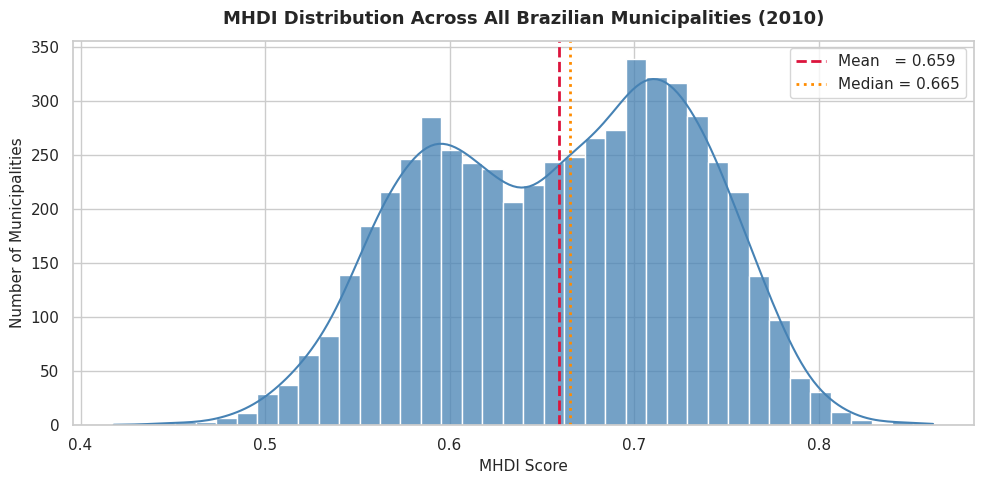

In [ ]:
# Histogram with mean and median lines
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_mhdi["MHDI"], bins=40, kde=True, color="steelblue", alpha=0.75, ax=ax)
ax.axvline(df_mhdi["MHDI"].mean(),   color="crimson",    linestyle="--", lw=2,
           label=f"Mean   = {df_mhdi['MHDI'].mean():.3f}")
ax.axvline(df_mhdi["MHDI"].median(), color="darkorange", linestyle=":",  lw=2,
           label=f"Median = {df_mhdi['MHDI'].median():.3f}")
ax.set_title("MHDI Distribution Across All Brazilian Municipalities (2010)", pad=12)
ax.set_xlabel("MHDI Score")
ax.set_ylabel("Number of Municipalities")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Insight: The Myth of the Average

The mean and median are nearly identical (both ≈ 0.66), which might suggest that inequality is not severe. It is not. The **range of 0.44 points** (0.42 to 0.86) tells a far more uncomfortable story:

- The lowest MHDI (0.42) falls in the **Low Human Development** category
- The highest (0.86) is **High Human Development**
- This gap is equivalent to the difference between a developing and a developed nation

> **The national average is a statistical mask. The story is in the extremes.**

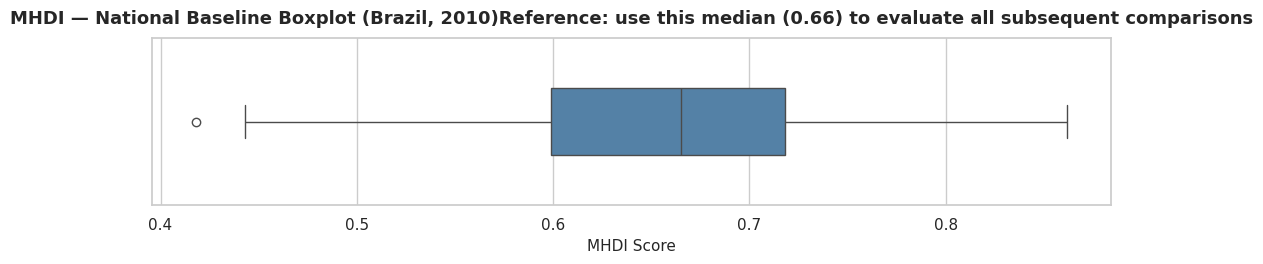

In [ ]:
# National boxplot — our reference baseline for all comparisons that follow
fig, ax = plt.subplots(figsize=(10, 2.8))
sns.boxplot(x=df_mhdi["MHDI"], color="steelblue", width=0.4, ax=ax)
ax.set_title("MHDI — National Baseline Boxplot (Brazil, 2010)"
             "Reference: use this median (0.66) to evaluate all subsequent comparisons", pad=10)
ax.set_xlabel("MHDI Score")
plt.tight_layout()
plt.show()

## 5. A Country of Contrasts — Regional Analysis

Brazil is continental in size, with profound geographic, historical, and economic differences across its five macro-regions. This section asks: **does the region a municipality belongs to predict its human development level?**

> **Hypothesis:** South and Southeast will score above the national mean; North and North East will fall below it.

In [ ]:
national_mean = df_mhdi["MHDI"].mean()

mhdi_region = (
    df_mhdi.groupby("Region")["MHDI"]
           .agg(["mean", "median", "std", "min", "max"])
           .round(3)
           .sort_values("mean")
           .reset_index()
)
mhdi_region.columns = ["Region", "Mean", "Median", "Std Dev", "Min", "Max"]
print(mhdi_region.to_string(index=False))
print(f"National mean: {national_mean:.3f}")

      Region  Mean  Median  Std Dev   Min   Max
  North East 0.591   0.588    0.043 0.443 0.788
       North 0.608   0.609    0.060 0.418 0.788
Central-West 0.689   0.692    0.037 0.526 0.824
   Southeast 0.699   0.705    0.054 0.529 0.862
       South 0.714   0.716    0.042 0.546 0.847
National mean: 0.659


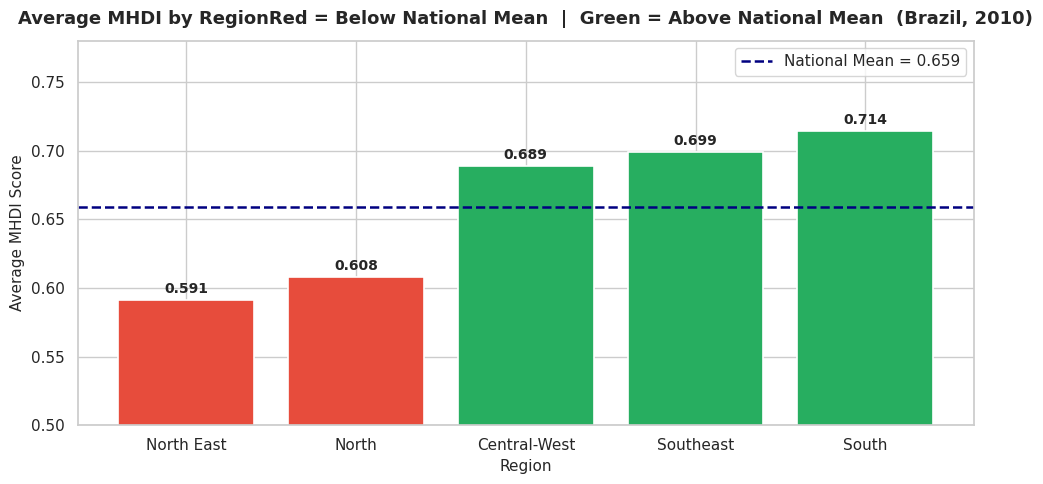

In [ ]:
# Bar chart coloured by position relative to national mean
means = mhdi_region.set_index("Region")["Mean"]
colors = ["#e74c3c" if v < national_mean else "#27ae60" for v in means.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(means.index, means.values, color=colors, edgecolor="white", linewidth=1.2)
ax.axhline(national_mean, color="navy", linestyle="--", lw=1.8,
           label=f"National Mean = {national_mean:.3f}")
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Average MHDI by Region"
             "Red = Below National Mean  |  Green = Above National Mean  (Brazil, 2010)", pad=12)
ax.set_xlabel("Region")
ax.set_ylabel("Average MHDI Score")
ax.set_ylim(0.50, 0.78)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Insight: The 0.12-Point Divide

The gap between the lowest region (North East) and the highest (South) is approximately **0.12 index points**. In absolute terms this looks small. In human terms it is not:

- **North East & North:** Below the national mean. Characterised by limited educational infrastructure, lower per-capita income, and decades of structural under-investment
- **Central-West:** Above average, driven by agribusiness (grain exports, livestock) and the federal district (Brasília)
- **Southeast:** Industrial and financial capital of Brazil — São Paulo alone generates ~30% of national GDP
- **South:** Three states, high social cohesion, a legacy of German and Italian immigrant communities historically associated with investment in education

> **A 0.12-point regional gap represents millions of people whose life outcomes are determined by the postcode of their birth.**

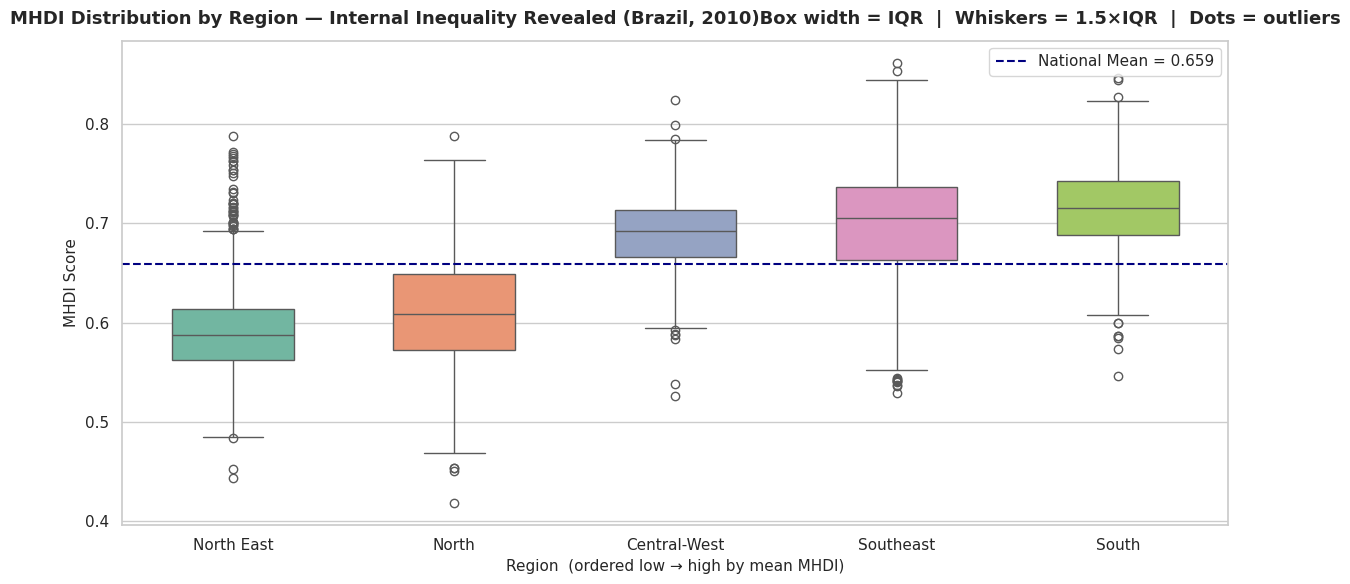

In [ ]:
# Boxplot by region — reveals within-region inequality, not just averages
region_order = mhdi_region.sort_values("Mean")["Region"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_mhdi, x="Region", y="MHDI", order=region_order,
            palette="Set2", width=0.55, ax=ax)
ax.axhline(national_mean, color="navy", linestyle="--", lw=1.5,
           label=f"National Mean = {national_mean:.3f}")
ax.set_title("MHDI Distribution by Region — Internal Inequality Revealed (Brazil, 2010)"
             "Box width = IQR  |  Whiskers = 1.5×IQR  |  Dots = outliers", pad=12)
ax.set_xlabel("Region  (ordered low → high by mean MHDI)")
ax.set_ylabel("MHDI Score")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Insight: The "Island" Effect

The North East boxplot reveals significant **upper outliers** — municipalities that outperform their regional peers by a wide margin. These are "islands of development": cities that, despite structural disadvantage, achieved high MHDI scores through concentrated investment or strong local governance.

The North East also shows the **widest interquartile range** of any region, meaning it is not simply a poor region — it is a profoundly *unequal* one with extreme internal variation.

> **The South's narrow box signals consistent development. The North East's wide box signals inequality within inequality.**

## 6. State-Level Deep Dive — 27 Different Realities

Regions group 27 states. Here we zoom in to see which individual states drive the regional averages — and which drag them down.

In [ ]:
# State-level means for all indicators, sorted by MHDI descending
df_state = (
    df_mhdi.groupby("State")[["MHDI","MHDI_Education","MHDI_Longevity","MHDI_Income"]]
           .mean()
           .round(3)
           .reset_index()
           .sort_values("MHDI", ascending=False)
           .reset_index(drop=True)
)

# Apply classification AFTER sorting (function defined in Section 3)
df_state["class"] = df_state.apply(mhdi_class, axis=1)

high = (df_state["class"] == "High Human Development").sum()
print(f"States classified as High Human Development: {high} / 27")
print()
print(df_state[["State","MHDI","MHDI_Education","MHDI_Longevity","MHDI_Income","class"]].to_string(index=False))

States classified as High Human Development: 1 / 27

              State  MHDI  MHDI_Education  MHDI_Longevity  MHDI_Income                    class
   Distrito Federal 0.824           0.742           0.873        0.863   High Human Development
          São Paulo 0.740           0.676           0.836        0.716 Medium Human Development
     Santa Catarina 0.732           0.637           0.847        0.728 Medium Human Development
  Rio Grande do Sul 0.714           0.601           0.840        0.722 Medium Human Development
     Rio de Janeiro 0.709           0.621           0.816        0.705 Medium Human Development
             Paraná 0.702           0.611           0.820        0.692 Medium Human Development
              Goiás 0.695           0.596           0.825        0.684 Medium Human Development
     Espírito Santo 0.692           0.591           0.826        0.681 Medium Human Development
        Mato Grosso 0.684           0.577           0.817        0.682 Medium Human

In [ ]:
# Interactive bar chart — data SORTED before creating figure
fig = px.bar(
    df_state,   # already sorted by MHDI descending
    x="State",
    y="MHDI",
    text="MHDI",
    color="class",
    color_discrete_map={
        "High Human Development":   "#27ae60",
        "Medium Human Development": "#f39c12",
        "Low Human Development":    "#e74c3c"
    },
    title="Average MHDI by State — Brazil 2010  (Sorted Highest to Lowest)",
    labels={"State": "State", "MHDI": "Average MHDI", "class": "Development Class"}
)
fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(xaxis_tickangle=-45, uniformtext_minsize=8,
                  uniformtext_mode="hide", height=520)
fig.show()

In [ ]:
# The poles — top 5 vs bottom 5 states
print("TOP 5 STATES:")
print(df_state.head(5)[["State","MHDI","MHDI_Education","MHDI_Longevity","MHDI_Income"]].to_string(index=False))
print("BOTTOM 5 STATES:")
print(df_state.tail(5)[["State","MHDI","MHDI_Education","MHDI_Longevity","MHDI_Income"]].to_string(index=False))

TOP 5 STATES:
            State  MHDI  MHDI_Education  MHDI_Longevity  MHDI_Income
 Distrito Federal 0.824           0.742           0.873        0.863
        São Paulo 0.740           0.676           0.836        0.716
   Santa Catarina 0.732           0.637           0.847        0.728
Rio Grande do Sul 0.714           0.601           0.840        0.722
   Rio de Janeiro 0.709           0.621           0.816        0.705
BOTTOM 5 STATES:
   State  MHDI  MHDI_Education  MHDI_Longevity  MHDI_Income
    Pará 0.582           0.449           0.774        0.572
Maranhão 0.576           0.489           0.741        0.532
   Piauí 0.571           0.456           0.749        0.547
Amazonas 0.565           0.437           0.766        0.545
 Alagoas 0.564           0.443           0.740        0.548


## 7. What Drives Development? — Decomposing the Three Pillars

The MHDI is not a single measurement. It is a composite of three dimensions:

| Pillar | What It Measures | Expected Pattern |
|--------|-----------------|------------------|
| **Education** | School enrolment & adult literacy | Weakest — most unequal across municipalities |
| **Longevity** | Life expectancy at birth | Strongest — national health programmes equalise outcomes |
| **Income** | Per-capita income index | Moderate — closely tied to Education |

> **Research Question 2:** Which pillar is most strongly correlated with overall MHDI?
> We answer this directly below using a correlation matrix that **includes MHDI itself** — unlike a sub-index heatmap, this directly identifies the dominant driver.

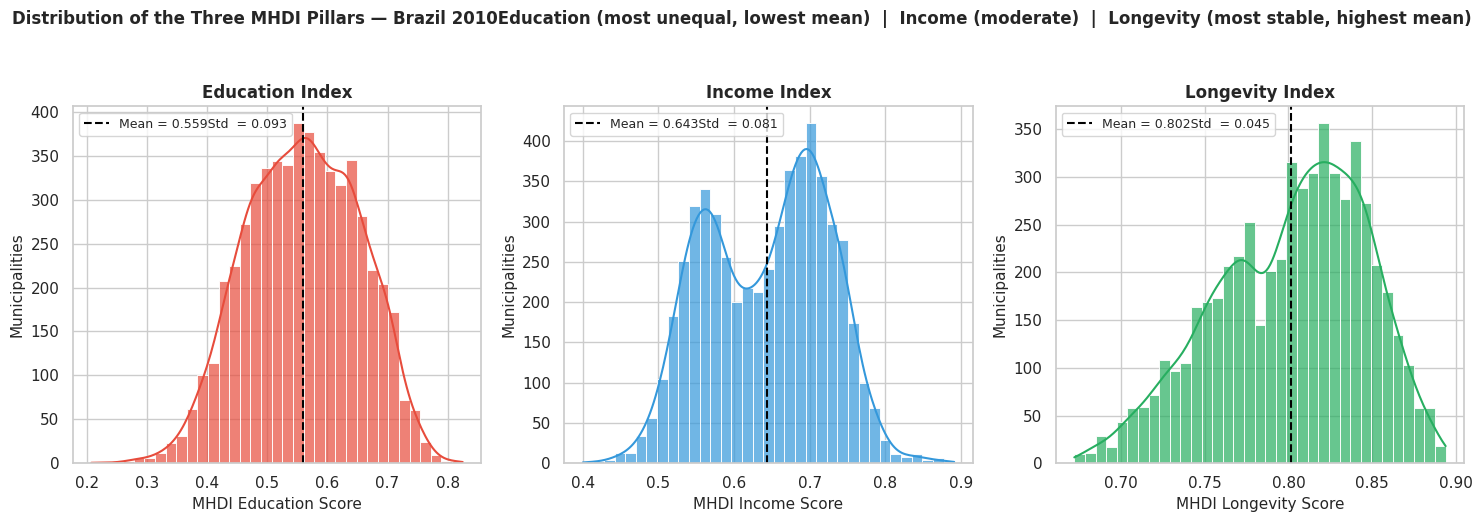

In [ ]:
# Side-by-side histograms for all three pillars — one comparative view
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pillar_config = [
    ("MHDI_Education", "#e74c3c", "Education"),
    ("MHDI_Income",    "#3498db", "Income"),
    ("MHDI_Longevity", "#27ae60", "Longevity"),
]

for ax, (col, color, label) in zip(axes, pillar_config):
    mean_val = df_mhdi[col].mean()
    std_val  = df_mhdi[col].std()
    sns.histplot(df_mhdi[col], bins=35, kde=True, color=color, alpha=0.7, ax=ax)
    ax.axvline(mean_val, color="black", linestyle="--", lw=1.5,
               label=f"Mean = {mean_val:.3f}Std  = {std_val:.3f}")
    ax.set_title(f"{label} Index", fontsize=12)
    ax.set_xlabel(f"MHDI {label} Score")
    ax.set_ylabel("Municipalities")
    ax.legend(fontsize=9)

fig.suptitle("Distribution of the Three MHDI Pillars — Brazil 2010"
    "Education (most unequal, lowest mean)  |  Income (moderate)  |  Longevity (most stable, highest mean)",
    fontsize=12, fontweight="bold", y=1.04
)
plt.tight_layout()
plt.show()

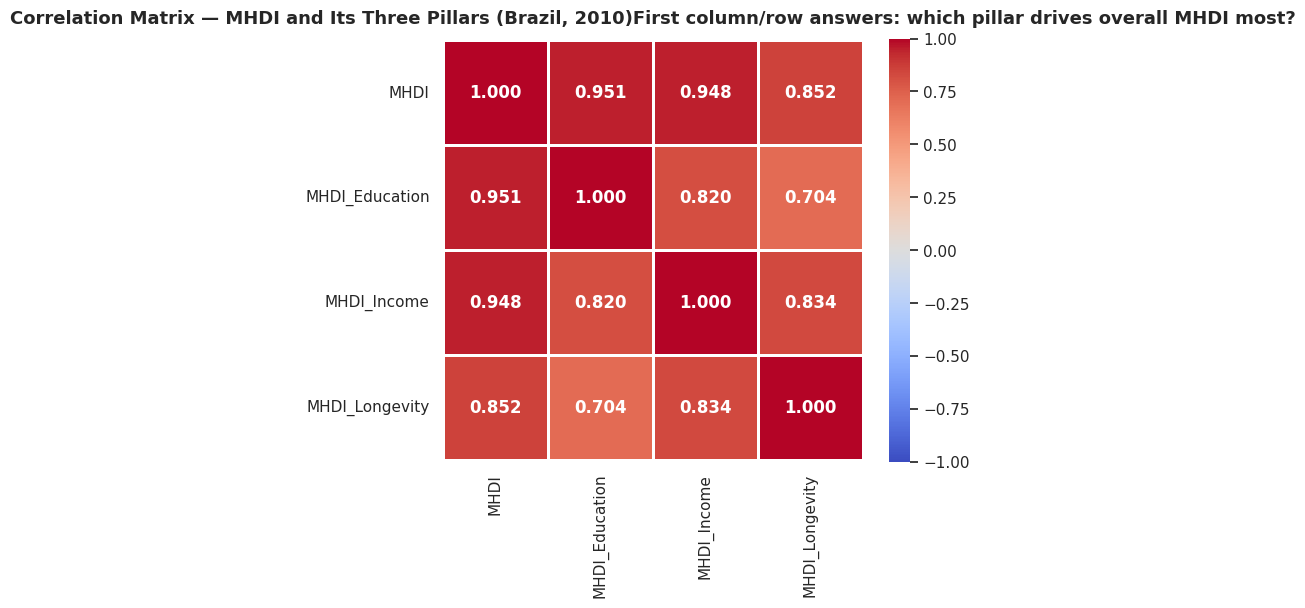

Correlation of each pillar with overall MHDI:
------------------------------------------
  MHDI_Education        : r = 0.951  ███████████████████████
  MHDI_Income           : r = 0.948  ███████████████████████
  MHDI_Longevity        : r = 0.852  █████████████████████
------------------------------------------
Answer to Research Question 2:
   MHDI_Education (r = 0.951) is most strongly correlated with MHDI.


In [ ]:
# Correlation matrix INCLUDING MHDI — directly answers Research Question 2
cols_corr = ["MHDI", "MHDI_Education", "MHDI_Income", "MHDI_Longevity"]
corr = df_mhdi[cols_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.8, square=True, ax=ax,
            annot_kws={"size": 12, "weight": "bold"})
ax.set_title(
    "Correlation Matrix — MHDI and Its Three Pillars (Brazil, 2010)"
    "First column/row answers: which pillar drives overall MHDI most?",
    pad=12
)
plt.tight_layout()
plt.show()

# Rank pillars by correlation with overall MHDI
pillar_corr = corr["MHDI"].drop("MHDI").sort_values(ascending=False)
print("Correlation of each pillar with overall MHDI:")
print("-" * 42)
for pillar, val in pillar_corr.items():
    bar = "█" * int(val * 25)
    print(f"  {pillar:<22}: r = {val:.3f}  {bar}")
print("-" * 42)
print(f"Answer to Research Question 2:")
print(f"   {pillar_corr.idxmax()} (r = {pillar_corr.max():.3f}) is most strongly correlated with MHDI.")

### Insight: Education Is the Achilles' Heel

The correlation matrix answers Research Question 2:

- **Education** shows the highest correlation with overall MHDI
- **Income** follows closely. the two pillars are deeply intertwined
- **Longevity** is the weakest predictor

This makes intuitive sense. Longevity is shaped by national public health policy (SUS, vaccination campaigns) which reaches even the most remote municipalities. Education, by contrast, requires local infrastructure — schools, teachers, transport — and tracks much more closely with economic resources.

> **A municipality's MHDI is primarily determined by how well it educates its population. Longevity follows from policy; development follows from education.**

## 8. Statistical Modelling — Quantifying the Relationships

With the correlations established visually, we now **quantify** them using linear regression.

**Part A:** R² comparison — which pillar best predicts MHDI?

**Part B:** Education → Income regression — modelling the mechanism of the poverty trap

In [ ]:
# Part A: R² comparison — which single pillar best predicts overall MHDI?
print("=" * 62)
print("SIMPLE LINEAR REGRESSION:  Each Pillar  →  Overall MHDI")
print("=" * 62)

r2_results = {}
for pillar in ["MHDI_Education", "MHDI_Income", "MHDI_Longevity"]:
    X = df_mhdi[[pillar]].values
    y = df_mhdi["MHDI"].values
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    r2_results[pillar] = r2
    print(f"  {pillar:<22}: R² = {r2:.4f}  → explains {r2*100:.1f}% of MHDI variance")

best = max(r2_results, key=r2_results.get)
print("=" * 62)
print(f"  Winner: {best}  (R² = {r2_results[best]:.4f})")

SIMPLE LINEAR REGRESSION:  Each Pillar  →  Overall MHDI
  MHDI_Education        : R² = 0.9042  → explains 90.4% of MHDI variance
  MHDI_Income           : R² = 0.8993  → explains 89.9% of MHDI variance
  MHDI_Longevity        : R² = 0.7262  → explains 72.6% of MHDI variance
  Winner: MHDI_Education  (R² = 0.9042)


REGRESSION:  Education Index  →  Income Index
  R²           : 0.6718  (67.2% of Income variance explained)
  Coefficient  : 0.7083
  Intercept    : 0.2469
 Interpretation: for every +0.10 in Education,
  Income increases by approximately +0.0708


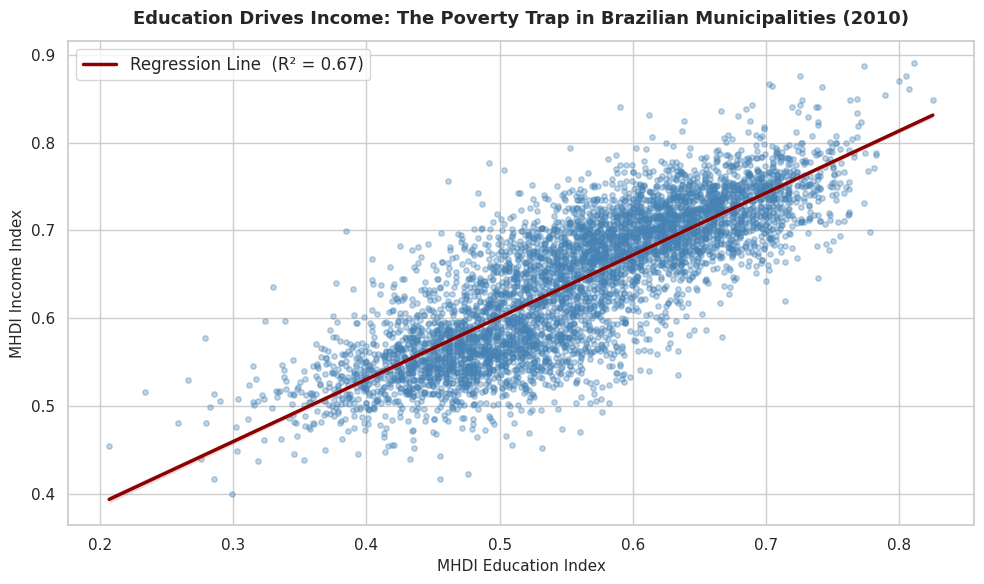

In [ ]:
# Part B: Education → Income — quantifying the poverty trap
X = df_mhdi[["MHDI_Education"]].values
y = df_mhdi["MHDI_Income"].values

model_ei  = LinearRegression().fit(X, y)
r2_ei     = model_ei.score(X, y)
coef      = model_ei.coef_.item()
intercept = model_ei.intercept_.item()

print("=" * 52)
print("REGRESSION:  Education Index  →  Income Index")
print("=" * 52)
print(f"  R²           : {r2_ei:.4f}  ({r2_ei*100:.1f}% of Income variance explained)")
print(f"  Coefficient  : {coef:.4f}")
print(f"  Intercept    : {intercept:.4f}")
print(f" Interpretation: for every +0.10 in Education,")
print(f"  Income increases by approximately +{coef*0.10:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    x="MHDI_Education", y="MHDI_Income", data=df_mhdi,
    scatter_kws={"alpha": 0.35, "color": "steelblue", "s": 15},
    line_kws={"color": "darkred", "linewidth": 2.5,
              "label": f"Regression Line  (R² = {r2_ei:.2f})"},
    ax=ax
)
ax.set_title("Education Drives Income: The Poverty Trap in Brazilian Municipalities (2010)", pad=12)
ax.set_xlabel("MHDI Education Index")
ax.set_ylabel("MHDI Income Index")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Insight: The Poverty Trap Quantified

The regression confirms what the correlation heatmap suggested: **~67% of the variation in a municipality's income is explained by its education level alone**.

The remaining 33% reflects factors not captured here such as local infrastructure, natural resource extraction, historical regional policies, and proximity to urban centres.

**This is the mechanism of the poverty trap:**
- Low education → low income
- Low income → less investment in schools and teachers
- Less investment → low education in the next generation

Breaking this cycle requires targeted educational investment, not merely economic stimulus.

## 9. Municipal-Level Analysis — Who Is Being Left Behind?

Averages describe the centre. Now we move to the **extremes** — the municipalities at the very top and bottom of Brazil's development spectrum, and the 32 towns that remain in Low Human Development.

> **Research Question 3:** Are there municipalities that perform significantly better or worse than others in the same region?

In [ ]:
# The 32 municipalities in Low Human Development
low_dev = (
    df_mhdi[df_mhdi["class"] == "Low Human Development"]
    [["Region","State","Municipality","MHDI","MHDI_Education","MHDI_Longevity","MHDI_Income"]]
    .sort_values("MHDI")
    .reset_index(drop=True)
)

print(f"{len(low_dev)} municipalities classified as Low Human Development")
print(f"Regions present : {sorted(low_dev['Region'].unique())}")
print(f"States present  : {sorted(low_dev['State'].unique())}")
low_dev

32 municipalities classified as Low Human Development
Regions present : ['North', 'North East']
States present  : ['Acre', 'Alagoas', 'Amazonas', 'Bahia', 'Maranhão', 'Pará', 'Pernambuco', 'Piauí', 'Roraima']


,Region,State,Municipality,MHDI,MHDI_Education,MHDI_Longevity,MHDI_Income
0,North,Pará,MELGAÇO,0.418,0.207,0.776,0.454
1,North East,Maranhão,FERNANDO FALCÃO,0.443,0.286,0.728,0.417
2,North,Amazonas,ATALAIA DO NORTE,0.450,0.259,0.733,0.481
3,North East,Maranhão,MARAJÁ DO SENA,0.452,0.299,0.774,0.400
4,North,Pará,CHAVES,0.453,0.234,0.769,0.516
5,North,Roraima,UIRAMUTÃ,0.453,0.276,0.766,0.439
6,North,Acre,JORDÃO,0.469,0.283,0.731,0.499
7,North,Pará,BAGRE,0.471,0.280,0.777,0.481
8,North,Pará,CACHOEIRA DO PIRIÁ,0.473,0.303,0.779,0.449
9,North,Amazonas,ITAMARATI,0.477,0.266,0.772,0.529


### Insight: The Geography of Deprivation

All 32 municipalities classified as **Low Human Development** are located exclusively in the **North or North East** — zero exceptions. They share a structural profile:

- **Education** is the lowest sub-index in every case without exception
- **Longevity** is surprisingly moderate even here (range 0.67–0.82) — evidence of national health programme reach
- **Income** is consistently the second weakest pillar

The worst municipality in Brazil — **Melgaço, Pará (MHDI 0.418)** — has an Education index of 0.207: roughly **half the national mean of 0.56**. This is not a gap, it is an abyss.

In [ ]:
# Top 10 and Bottom 10 municipalities
N = 10
top    = df_mhdi.nlargest(N, "MHDI")[["Municipality","State","Region","MHDI"]].copy()
bottom = df_mhdi.nsmallest(N, "MHDI")[["Municipality","State","Region","MHDI"]].copy()
top["Rank"]    = "Top 10"
bottom["Rank"] = "Bottom 10"
ranking = pd.concat([top, bottom]).reset_index(drop=True)
ranking

,Municipality,State,Region,MHDI,Rank
0,SÃO CAETANO DO SUL,São Paulo,Southeast,0.862,Top 10
1,ÁGUAS DE SÃO PEDRO,São Paulo,Southeast,0.854,Top 10
2,FLORIANÓPOLIS,Santa Catarina,South,0.847,Top 10
3,VITÓRIA,Espírito Santo,Southeast,0.845,Top 10
4,BALNEÁRIO CAMBORIÚ,Santa Catarina,South,0.845,Top 10
5,SANTOS,São Paulo,Southeast,0.840,Top 10
6,NITERÓI,Rio de Janeiro,Southeast,0.837,Top 10
7,JOAÇABA,Santa Catarina,South,0.827,Top 10
8,BRASÍLIA,Distrito Federal,Central-West,0.824,Top 10
9,CURITIBA,Paraná,South,0.823,Top 10


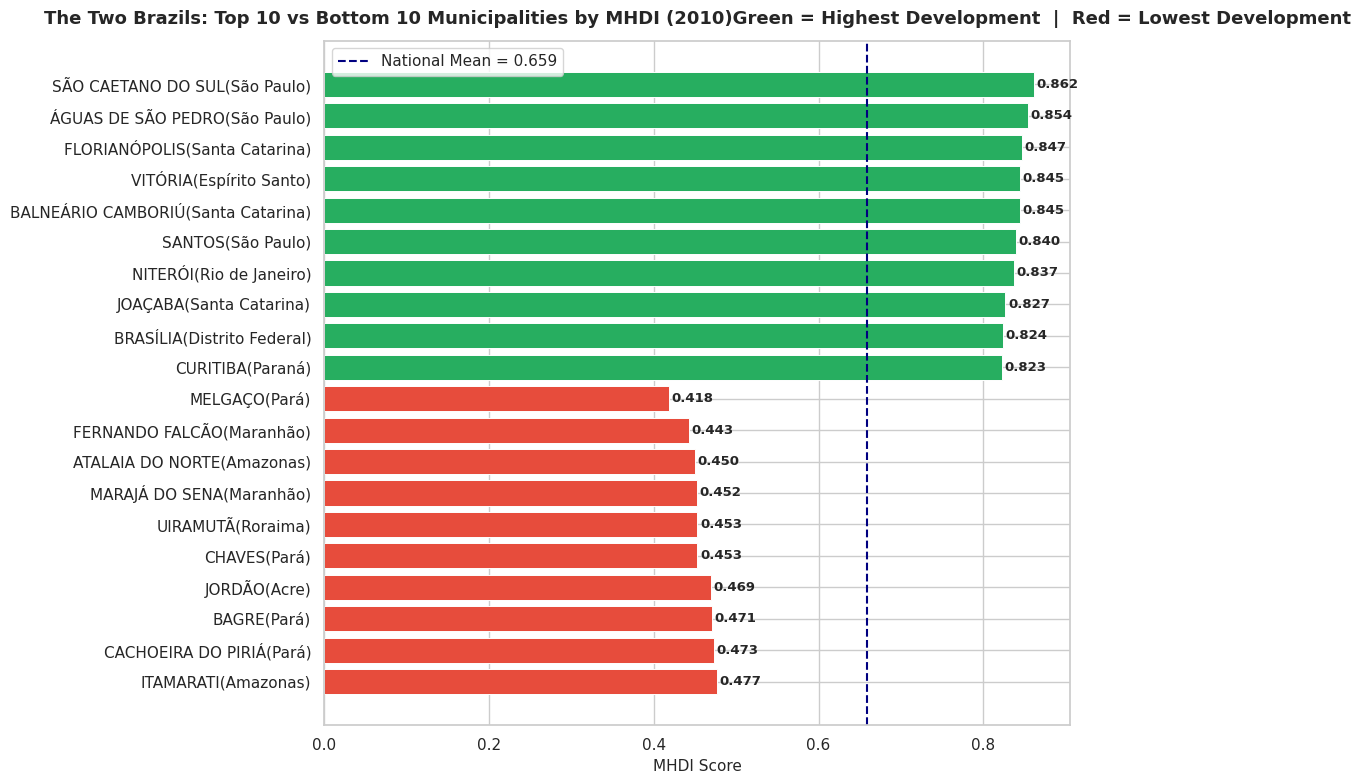

In [ ]:
# Horizontal bar chart — the two Brazils side by side
fig, ax = plt.subplots(figsize=(11, 8))

colors = ["#27ae60" if r == "Top 10" else "#e74c3c" for r in ranking["Rank"]]
labels = ranking["Municipality"] + "(" + ranking["State"] + ")"

bars = ax.barh(labels, ranking["MHDI"], color=colors, edgecolor="white", linewidth=0.7)
ax.axvline(df_mhdi["MHDI"].mean(), color="navy", linestyle="--", lw=1.5,
           label=f"National Mean = {df_mhdi['MHDI'].mean():.3f}")

for bar, val in zip(bars, ranking["MHDI"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9.5, fontweight="bold")

ax.set_title(
    "The Two Brazils: Top 10 vs Bottom 10 Municipalities by MHDI (2010)"
    "Green = Highest Development  |  Red = Lowest Development",
    pad=12
)
ax.set_xlabel("MHDI Score")
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

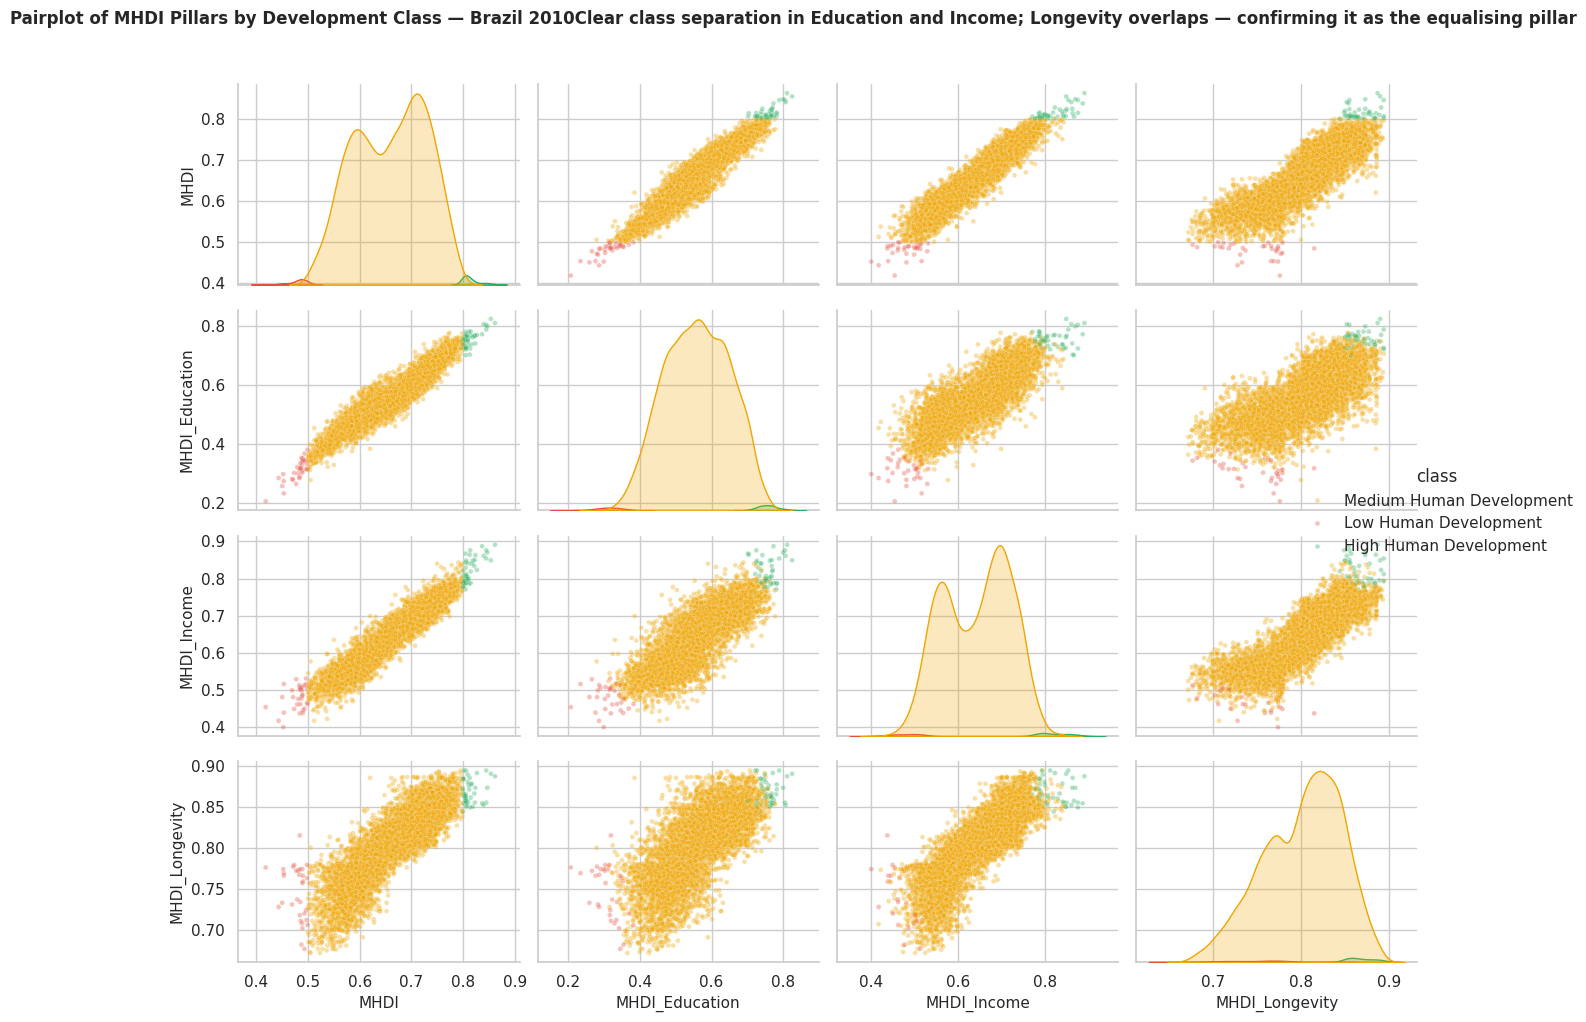

In [ ]:
# Pairplot coloured by development class — multivariate outlier detection
pair_df = df_mhdi[["MHDI","MHDI_Education","MHDI_Income","MHDI_Longevity","class"]].copy()

g = sns.pairplot(
    pair_df,
    hue="class",
    palette={
        "High Human Development":   "#27ae60",
        "Medium Human Development": "#f0a500",
        "Low Human Development":    "#e74c3c"
    },
    plot_kws={"alpha": 0.35, "s": 12},
    diag_kind="kde"
)
g.fig.suptitle("Pairplot of MHDI Pillars by Development Class — Brazil 2010"
    "Clear class separation in Education and Income; Longevity overlaps — confirming it as the equalising pillar",
    y=1.02, fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 10. Final Insights

---

### Insight 1 · The Myth of the Average
Brazil's national MHDI average of **0.66** is technically accurate and practically misleading. At the national level mean ≈ median, suggesting symmetry. But that symmetry conceals a 0.44-point range between the best and worst municipalities. The country is **polarised**, a national average calculated over 5,564 municipalities hides the fact that some of those municipalities live in conditions more comparable to Sub-Saharan Africa than to the São Paulo metropolitan area.

---

### Insight 2 · Education Is the Achilles' Heel
Across all regions, all states, and across the regression analysis, **Education** emerges as the weakest pillar and the strongest predictor of overall MHDI. It has the lowest mean (~ 0.56), the highest standard deviation (~ 0.09), and the highest correlation with the composite index. Even in economically stronger states, educational attainment lags behind income gains. This creates a structural ceiling: wealth can grow in the short term, but without educational investment it cannot compound across generations.

---

### Insight 3 · Longevity Is the Great Equaliser
**Longevity** is the most stable and highest-scoring pillar across Brazil (mean ~0.80, std ~0.04). Life expectancy is relatively high even in Brazil's most deprived municipalities — evidence that national public health programmes (SUS, vaccination campaigns) have reached remote communities. This is a genuine policy success story embedded in the data: **health outcomes can decouple from economic conditions when policy is well-designed and well-funded**.

---

### Insight 4 · The "Island" Effect — Local Governance Matters
The North East boxplot reveals municipalities that substantially outperform their regional context. These "islands of development" demonstrate that geography is not destiny. Localised investment, specific economic activities, and strong municipal governance can counteract broad structural disadvantage. Identifying and understanding these cases is arguably more actionable than top-down national policy.

---

### Insight 5 · The Poverty Trap
The Education → Income regression (R² ≈ 0.67) quantifies a well-known but often under-evidenced mechanism: municipalities with low education have low income, and low income limits investment in education. This circular reinforcement explains why all 32 **Low Human Development** municipalities cluster in the same geographic areas. The data does not just describe inequality — it reveals its engine.

---

### Research Questions — Answered

| # | Question | Answer |
|---|----------|--------|
| 1 | How is development distributed? | Symmetric nationally (mean ≈ median = 0.66) but deeply polarised geographically between South/Southeast and North/North East |
| 2 | Which pillar drives MHDI most? | **Education** — highest correlation with MHDI and highest R² in regression |
| 3 | Do outlier municipalities exist? | Yes — Top 10 are in South/Southeast; Bottom 10 exclusively in North/North East; "islands" of high performance visible in the North East |

## 11. Conclusions and Next Steps

This notebook used the 2010 MHDI as a lens to tell the story of development inequality in Brazil. Starting from clear research questions, the analysis moved from national summaries → regional comparisons → state rankings → pillar decomposition → statistical modelling → municipal outlier identification — each step building on the last to deepen the narrative.

### What Was Confirmed
- The North-South divide is real and measurable: a ~0.12-point regional gap between North East and South
- Education is the primary driver **and** the primary constraint on human development
- Longevity is the most equitable pillar — evidence that targeted national health policy works
- 32 municipalities remain in Low Human Development — all in North or North East

### What Was Unexpected
- The national distribution is approximately symmetric (mean ≈ median). The inequality is *spatial*, not distributional
- Some North East municipalities substantially outperform their regional context — the "island" effect

### Limitations
- 2010 data cannot capture post-pandemic or post-2014 economic crisis effects
- Sub-index correlations with MHDI are partly definitional (MHDI is a geometric mean of sub-indices)

### Suggested Next Steps
1. **Temporal comparison:** Apply the same methodology to the 2021 Census for trend analysis
2. **Spatial mapping:** Use GeoPandas/Folium to build a choropleth and test for spatial autocorrelation.
3. **Multi-variate modelling:** Incorporate environmental indicators like CO2 and deforestation for a more modern view of development.

---
*Analysis by Student L00196791  |  Data: Atlas do Desenvolvimento Humano no Brasil 2010 (UNDP/IPEA/FJP)*